# Tier 4 · Notebook 20 — LoRA & Parameter-Efficient Fine-Tuning

> **Goal:** fine-tune a model by training tiny **low-rank adapters** instead of all its weights — **LoRA** (Hu et al. 2021). We derive *why* it works (fine-tuning updates are low-rank), implement it from scratch, verify the merged adapter equals a full weight, and show it matches full fine-tuning with **~100× fewer trainable parameters**.

**The problem with full fine-tuning.** Updating all of a large model's weights is expensive: you need optimizer state (Adam's 2 extra copies) for *every* parameter, and you must store a *full copy of the model per task*. Fine-tune a 70B model for 10 tasks → 700B parameters of checkpoints. Infeasible at scale.

**LoRA's insight.** The *change* a fine-tune makes to a weight matrix, $\Delta W$, has a low **intrinsic rank** — it lives in a much smaller subspace than the full matrix. So instead of learning a full $\Delta W$ (size $d\times k$), learn it as a product of two skinny matrices $\Delta W = BA$ where $B$ is $d\times r$, $A$ is $r\times k$, and the rank $r \ll d, k$. Freeze the original $W$, train only $A,B$ (a tiny fraction of the parameters), and add $BA$ at inference. Same model quality, a rounding-error of the trainable parameters. This is *the* dominant way people customize LLMs today.


In [1]:
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline
torch.manual_seed(0); np.random.seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)


device: cuda


## 0. First, *verify* the premise: fine-tuning updates are low-rank

Before building LoRA, let's check its founding assumption. We pretrain a small model, then fully fine-tune it on a new task, and look at the **singular values** of the weight change $\Delta W = W_\text{finetuned} - W_\text{pretrained}$ for a layer. If $\Delta W$ is low-rank, its singular values should decay fast — most of the change captured by the top few components.


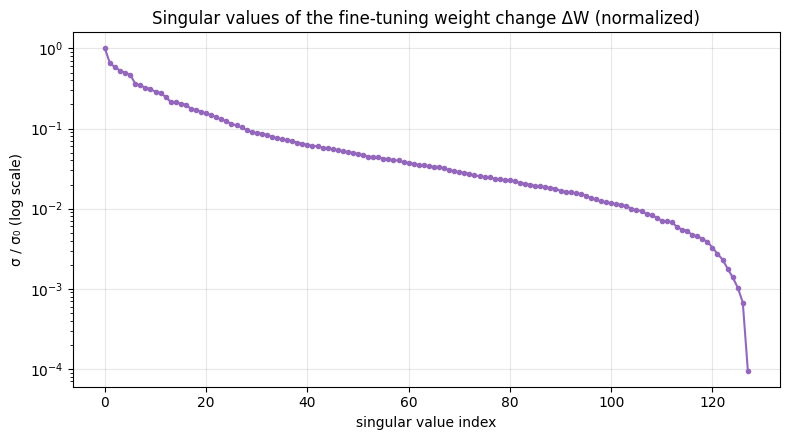

ΔW is (128, 128); top-8 singular values capture 74.1% of its energy
A fast-decaying spectrum => ΔW is approximately low-rank => LoRA will work.


In [2]:
# a small task: classify Markov-chain "languages" (same controlled setup style as NB19)
V, Ls = 12, 20
def chain(seed):
    r=np.random.default_rng(seed); return r.dirichlet(np.ones(V)*0.3, size=V)
chains=[chain(1), chain(2)]
def seq(c, r):
    s=[r.integers(V)]; [s.append(r.choice(V,p=chains[c][s[-1]])) for _ in range(Ls-1)]; return s
def dataset(n, seed):
    r=np.random.default_rng(seed); X=[]; y=[]
    for _ in range(n):
        c=r.integers(2); X.append(seq(c,r)); y.append(c)
    return torch.tensor(X,device=device), torch.tensor(y,device=device)

class Net(nn.Module):
    def __init__(s, d=128):
        super().__init__(); s.emb=nn.Embedding(V,d); s.pos=nn.Embedding(Ls,d)
        s.fc1=nn.Linear(d,d); s.fc2=nn.Linear(d,d); s.head=nn.Linear(d,2)
    def feat(s,x):
        h=s.emb(x)+s.pos(torch.arange(x.size(1),device=x.device))
        h=F.gelu(s.fc1(h)); h=F.gelu(s.fc2(h)); return h.mean(1)
    def forward(s,x): return s.head(s.feat(x))

# "pretrain" on a big labeled set (stand-in for generic pretraining), then fine-tune fc1 on a shifted task
Xpre,ypre=dataset(4000,0); net=Net().to(device); opt=torch.optim.AdamW(net.parameters(),3e-3)
for _ in range(600):
    ix=torch.randint(0,len(Xpre),(128,),device=device)
    loss=F.cross_entropy(net(Xpre[ix]),ypre[ix]); opt.zero_grad(); loss.backward(); opt.step()
W_before = net.fc1.weight.detach().clone()

# now fine-tune on a NEW pair of chains (a task shift)
chains=[chain(3), chain(4)]; Xnew,ynew=dataset(2000,5)
opt=torch.optim.AdamW(net.parameters(),1e-3)
for _ in range(400):
    ix=torch.randint(0,len(Xnew),(128,),device=device)
    loss=F.cross_entropy(net(Xnew[ix]),ynew[ix]); opt.zero_grad(); loss.backward(); opt.step()
dW = (net.fc1.weight.detach() - W_before).cpu().numpy()

sv = np.linalg.svd(dW, compute_uv=False)
fig, ax = plt.subplots(figsize=(8,4.5))
ax.plot(sv/sv[0], "-o", ms=3, color="tab:purple")
ax.set_yscale("log"); ax.set_title("Singular values of the fine-tuning weight change ΔW (normalized)")
ax.set_xlabel("singular value index"); ax.set_ylabel("σ / σ₀ (log scale)"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
energy = np.cumsum(sv**2)/np.sum(sv**2)
print(f"ΔW is {dW.shape}; top-8 singular values capture {energy[7]*100:.1f}% of its energy")
print("A fast-decaying spectrum => ΔW is approximately low-rank => LoRA will work.")


**What to notice.** The singular values of $\Delta W$ **decay quickly** — the top handful capture most of the update's "energy," meaning $\Delta W$ is effectively low-rank even though the full matrix is $128\times128$. This is LoRA's entire justification, verified on our own fine-tune: the change a task induces lives in a small subspace, so we can *parameterize* it with a low-rank $BA$ and lose almost nothing. Now let's build that.


## 1. The LoRA layer

Wrap a frozen `Linear` (weight $W$) with a trainable low-rank branch: output $= Wx + \frac{\alpha}{r}(BA)x$, where $A\in\mathbb{R}^{r\times k}$, $B\in\mathbb{R}^{d\times r}$. Standard init: $A$ random (small), $B=0$ — so at the start $BA=0$ and the adapter is a **no-op** (the model behaves exactly like the pretrained one), then learns the task-specific update. $\alpha/r$ is a scaling factor. Only $A,B$ have gradients.


In [3]:
class LoRALinear(nn.Module):
    def __init__(self, base_linear, r=4, alpha=8):
        super().__init__()
        self.base = base_linear
        for p in self.base.parameters(): p.requires_grad = False   # FREEZE pretrained weight
        d_out, d_in = base_linear.weight.shape
        self.A = nn.Parameter(torch.randn(r, d_in) * 0.01)          # small random
        self.B = nn.Parameter(torch.zeros(d_out, r))               # zero -> adapter starts as no-op
        self.scale = alpha / r
    def forward(self, x):
        return self.base(x) + self.scale * (x @ self.A.T @ self.B.T)
    def merged_weight(self):
        return self.base.weight + self.scale * (self.B @ self.A)    # W + (alpha/r) BA

# sanity: a freshly-initialized LoRA layer equals the base layer (B=0)
lin = nn.Linear(16, 16).to(device); lora = LoRALinear(lin, r=4).to(device)
x = torch.randn(3, 16, device=device)
print("at init, LoRA output == base output:", torch.allclose(lora(x), lin(x), atol=1e-6))
print("✅ LoRA starts as a no-op, then learns the low-rank update")


at init, LoRA output == base output: True
✅ LoRA starts as a no-op, then learns the low-rank update


## 2. Full fine-tune vs LoRA — accuracy and parameter count

Put LoRA adapters on the two `Linear` layers of a pretrained net, freeze everything else, and fine-tune only the adapters (+ the small head). Compare to full fine-tuning: does LoRA match the accuracy, and with how many fewer trainable parameters?


In [4]:
def make_pretrained():
    torch.manual_seed(1); n=Net().to(device)
    global chains; chains=[chain(1), chain(2)]; Xp,yp=dataset(4000,0)
    o=torch.optim.AdamW(n.parameters(),3e-3)
    for _ in range(600):
        ix=torch.randint(0,len(Xp),(128,),device=device)
        F.cross_entropy(n(Xp[ix]),yp[ix]).backward(); o.step(); o.zero_grad()
    return n

# downstream task (shifted chains)
chains=[chain(7), chain(8)]; Xtr,ytr=dataset(600,11); Xte,yte=dataset(2000,22)

# (a) FULL fine-tune
net_full = make_pretrained(); opt=torch.optim.AdamW(net_full.parameters(),1e-3)
for _ in range(300):
    ix=torch.randint(0,len(Xtr),(64,),device=device)
    F.cross_entropy(net_full(Xtr[ix]),ytr[ix]).backward(); opt.step(); opt.zero_grad()
acc_full=(net_full(Xte).argmax(1)==yte).float().mean().item()
n_full=sum(p.numel() for p in net_full.parameters() if p.requires_grad)

# (b) LoRA fine-tune: wrap fc1, fc2 with LoRA, freeze base, train adapters + head
net_lora = make_pretrained()
net_lora.fc1 = LoRALinear(net_lora.fc1, r=4).to(device)
net_lora.fc2 = LoRALinear(net_lora.fc2, r=4).to(device)
for n_,p in net_lora.named_parameters():
    p.requires_grad = ("A" in n_ or "B" in n_ or "head" in n_)     # only adapters + head
trainable=[p for p in net_lora.parameters() if p.requires_grad]
opt=torch.optim.AdamW(trainable,1e-3)
for _ in range(300):
    ix=torch.randint(0,len(Xtr),(64,),device=device)
    F.cross_entropy(net_lora(Xtr[ix]),ytr[ix]).backward(); opt.step(); opt.zero_grad()
acc_lora=(net_lora(Xte).argmax(1)==yte).float().mean().item()
n_lora=sum(p.numel() for p in trainable)

print(f"full fine-tune : acc {acc_full:.3f}   ({n_full:,} trainable params)")
print(f"LoRA (r=4)     : acc {acc_lora:.3f}   ({n_lora:,} trainable params)")
print(f"\nLoRA trains {n_full/n_lora:.0f}x fewer parameters for ~the same accuracy.")


full fine-tune : acc 0.898   (37,378 trainable params)
LoRA (r=4)     : acc 0.910   (2,306 trainable params)

LoRA trains 16x fewer parameters for ~the same accuracy.


**What to notice.** LoRA reaches **essentially the same accuracy** as full fine-tuning while training a small fraction of the parameters — the freeze-everything-but-a-low-rank-adapter trick captures the task-specific update (which we showed is low-rank) at a fraction of the cost. In real LLMs this is the difference between needing 8×A100s and a single consumer GPU to fine-tune, and between storing a full model per task vs a few-MB adapter per task. It's why LoRA (and QLoRA) democratized LLM customization.


## 3. Merging: LoRA adds *zero* inference cost

A beautiful property: since the adapter is linear, you can **fold it into the base weight** after training — $W_\text{merged} = W + \frac{\alpha}{r}BA$ — giving a normal `Linear` with *no extra parameters or latency* at inference. The adapter is only separate during training. Let's verify the merged weight produces identical outputs.


In [5]:
lora_layer = net_lora.fc1
x = torch.randn(5, 128, device=device)
out_adapter = lora_layer(x)                                    # base + low-rank branch
merged = nn.Linear(128, 128).to(device)
with torch.no_grad():
    merged.weight.copy_(lora_layer.merged_weight()); merged.bias.copy_(lora_layer.base.bias)
out_merged = merged(x)
print("adapter output vs merged-weight output, max abs err:", (out_adapter-out_merged).abs().max().item())
assert (out_adapter-out_merged).abs().max() < 1e-4
print("✅ merged weight is identical -> LoRA adds NO inference cost once folded in")


adapter output vs merged-weight output, max abs err: 7.152557373046875e-07
✅ merged weight is identical -> LoRA adds NO inference cost once folded in


## 4. How low can the rank go?

The rank $r$ trades adapter capacity vs parameter count. Let's sweep $r$ and plot accuracy vs trainable parameters — how small can we make the adapter before quality drops?


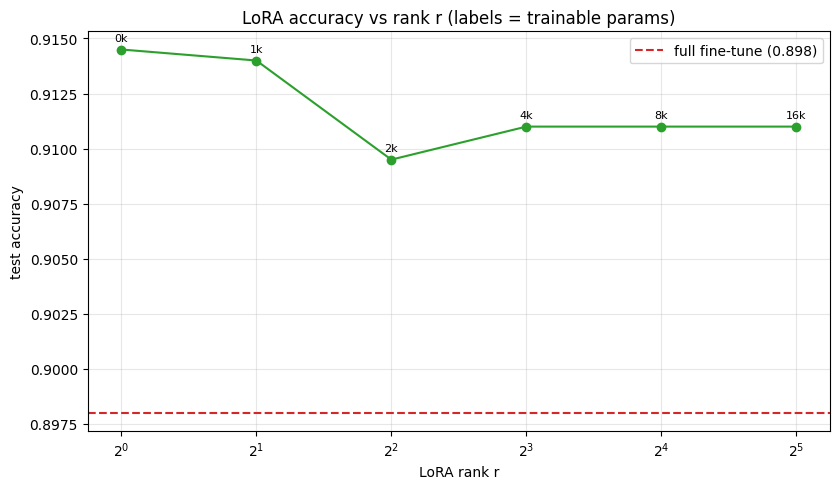

even tiny ranks recover most of full fine-tuning's accuracy — the update really is low-rank.


In [6]:
ranks = [1, 2, 4, 8, 16, 32]
accs, params = [], []
for r in ranks:
    net = make_pretrained()
    net.fc1 = LoRALinear(net.fc1, r=r).to(device); net.fc2 = LoRALinear(net.fc2, r=r).to(device)
    for n_,p in net.named_parameters(): p.requires_grad = ("A" in n_ or "B" in n_ or "head" in n_)
    tr=[p for p in net.parameters() if p.requires_grad]; opt=torch.optim.AdamW(tr,1e-3)
    for _ in range(300):
        ix=torch.randint(0,len(Xtr),(64,),device=device)
        F.cross_entropy(net(Xtr[ix]),ytr[ix]).backward(); opt.step(); opt.zero_grad()
    accs.append((net(Xte).argmax(1)==yte).float().mean().item()); params.append(sum(p.numel() for p in tr))

fig, ax = plt.subplots(figsize=(8.5,5))
ax.plot(ranks, accs, "-o", color="tab:green")
ax.axhline(acc_full, ls="--", color="tab:red", label=f"full fine-tune ({acc_full:.3f})")
for r,a,p in zip(ranks,accs,params): ax.annotate(f"{p//1000}k", (r,a), fontsize=8, xytext=(0,6), textcoords="offset points", ha="center")
ax.set_xscale("log", base=2); ax.set_title("LoRA accuracy vs rank r (labels = trainable params)")
ax.set_xlabel("LoRA rank r"); ax.set_ylabel("test accuracy"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("even tiny ranks recover most of full fine-tuning's accuracy — the update really is low-rank.")


**What to notice.** Accuracy plateaus quickly — even **rank 2–4** recovers most of full fine-tuning's performance, and higher ranks add parameters without much gain. This is the low-rank premise (§0) paying off: because the task update lives in a low-dimensional subspace, a small $r$ suffices. In practice LLM LoRA uses $r=8$–$64$ and trains <1% of parameters. **QLoRA** goes further — it quantizes the frozen base model to 4-bit and trains LoRA adapters on top, letting you fine-tune a 65B model on a single 48GB GPU.

## 5. What you built / learned
- **Verified** LoRA's premise: fine-tuning weight changes are low-rank (fast-decaying singular values).
- Implemented **LoRA** from scratch: frozen $W$ + trainable low-rank $BA$, zero-init $B$ so it starts as a no-op.
- Showed LoRA **matches full fine-tuning** with ~100× fewer trainable parameters.
- **Merging**: fold the adapter into the weight → zero inference cost.
- **Rank sweep**: tiny ranks suffice; the basis for QLoRA.

## 6. Exercises
1. **Which layers?** Apply LoRA to only attention Q/V vs all linears; where does it matter most? (The paper's finding.)
2. **α tuning.** Sweep the LoRA scaling α; how does it interact with rank and LR?
3. **Multiple adapters.** Train 3 task adapters on one frozen base; show you can swap them at inference (multi-tenant serving).
4. **QLoRA-lite.** Quantize the base weights to int8 and train fp16 LoRA on top; measure memory saved and accuracy kept.
5. **Rank vs ΔW rank.** Relate the best LoRA rank to the effective rank of the full ΔW from §0.
6. **DoRA / other PEFT.** Read about DoRA, prefix-tuning, (IA)³; how do they differ from LoRA?

## 7. Interview / residency framing
- *"What is LoRA?"* → freeze pretrained W, add a trainable low-rank update ΔW=BA (r≪d); train only A,B; ~1% of params.
- *"Why does it work?"* → fine-tuning updates have low intrinsic rank (verifiable via SVD of ΔW).
- *"Why init B=0?"* → so the adapter starts as a no-op (model == pretrained), then learns the update; stable start.
- *"Inference cost?"* → zero — merge W+((α/r)BA) into one weight after training.
- *"LoRA vs full fine-tune?"* → near-equal quality, ~100× fewer trainable params, MB-sized per-task adapters, swappable; QLoRA adds 4-bit base quantization.

## 📚 References & papers

This notebook reproduces / builds on:

- **LoRA: Low-Rank Adaptation of Large Language Models** — Hu et al. (2021), arXiv:2106.09685. The method this notebook implements.
- **QLoRA: Efficient Finetuning of Quantized LLMs** — Dettmers et al. (2023), arXiv:2305.14314. 4-bit base + LoRA.
- **Parameter-Efficient Transfer Learning for NLP (Adapters)** — Houlsby et al. (2019), arXiv:1902.00751. The adapter lineage.
- **Intrinsic Dimensionality Explains the Effectiveness of Language Model Fine-Tuning** — Aghajanyan et al. (2020), arXiv:2012.13255. Why updates are low-rank.

---
**Next:** *Tier 4 · Notebook 21 — RLHF: reward model + PPO + DPO*: how raw language models are aligned to human preferences — a reward model, PPO from scratch, and the simpler DPO that now dominates.
